In [3]:
import os
import matplotlib.pylab as plt
import stpsf
import numpy as np
import matplotlib
import pandas as pd


# Roman Post-SCIPA Wavefront Model in STPSF

## A compact parametric representation of the post-SCIPA wavefront model



This notebook documents the methodology used to incorporate the latest Roman Wide Field Instrument (WFI) optical model into STPSF.

[NASA's post-SCIPA](https://roman-docs.stsci.edu/roman-instruments/the-wide-field-instrument/wfi-characterization-activities/wfi-ground-testing-campaigns#WFIGroundTestingCampaigns-SCIPA) optical model provides substantially denser field sampling across each detector, including a 5×5 grid of field positions. Representing all of these optical maps directly, however, would significantly increase the size of the STPSF reference-data package.

We therefore developed a compact wavefront representation based on two components:

1. Field-dependent Zernike coefficients through Z210, which describe the spatially varying low- and intermediate-spatial-frequency wavefront structure.
2. A detector-specific high-frequency residual map, which preserves spatial structure that is not efficiently represented by the Zernike expansion.

This representation allows STPSF to retain the additional field information provided by the post-SCIPA model while keeping the reference-data package practical for distribution and use.

> **Key Result**
>
> The new STPSF implementation increases the field sampling from 5 field positions to 25 field positions (5×5) per detector.
The compact Zernike + high-frequency representation reconstructs the original post-SCIPA wavefront maps with an RMS residual of approximately 12 nm.

## Methodology Schematic


<img src="./roman_figures/data_diagram.png"
     alt="Phase Map Decomposition"
     width="1400">

**Caption**

*STPSF - Roman Post-SCIPA Methodology Schematic*

## Post-SCIPA Optical Delivery

Historically, Roman STPSF releases contained optical information at only five field positions per detector.

The post-SCIPA delivery introduced:

- 25 field points per detector.
- Full wavefront maps at each field location.
- Eight WFI imaging filters.
- Prism and grism modes.

The new 5×5 sampling pattern provides significantly improved characterization of field-dependent aberrations across the focal plane.

## Data Volume Challenge

For every detector, filter, and field position, the optical delivery contains a complete phase map.

$$
N_{maps} = N_{detector} \times N_{filter} \times 25
$$

Storing these phase maps directly would substantially increase the size of the STPSF data distribution.

A compression strategy was therefore developed that preserves optical realism while maintaining a manageable data package.

## Model-based representation

After removing a global piston term, each phase map is represented as a Zernike expansion:

$$
W(\rho,\theta)=\sum_{i=1}^{210} a_i Z_i(\rho,\theta)+R(\rho,\theta)
$$

where:

- $a_i$ are the fitted coefficients,
- $Z_i$ are Zernike polynomials,
- $R$ is the residual phase map.

Each post-SCIPA wavefront map is decomposed into a Zernike representation through Z210 and a residual map. The Zernike coefficients capture the low- and intermediate-spatial-frequency structure of the wavefront, while the residual contains structure that is not efficiently represented by the finite Zernike basis.

## Figure 1 — Phase Map Decomposition


<img src="./roman_figures/comparison_phase_maps.png"
     alt="Phase Map Decomposition"
     width="1000">

**Caption**

*Example decomposition of a post-SCIPA phase map. Left: original wavefront map. Center: reconstruction using Zernike terms through Z210. Right: residual after subtraction. The residual contains primarily high-spatial-frequency structure that is not efficiently represented by the Zernike basis.*

Inspection of the decomposition demonstrates that the majority of the optical power is captured by the Zernike representation. The remaining structure primarily consists of detector-scale high-frequency structure that is not efficiently represented by the finite Zernike basis.

## Choosing the Zernike Order

The number of retained Zernike coefficients determines the trade-off between reconstruction accuracy and data volume.

Increasing the Zernike order progressively reduces the reconstruction residual. At sufficiently high orders, however, the improvement becomes increasingly small because the remaining error is dominated by high-spatial-frequency structure.

The convergence study shows that Z210 provides a useful balance between reconstruction accuracy and data volume and was therefore selected for the STPSF implementation.

## Figure 2 — Reconstruction Performance Versus Zernike Order

Insert:


<img src="./roman_figures/zernike_numbers.png"
     alt="Zernike Terms"
     width="600">

**Caption**

*Wavefront reconstruction fidelity as a function of Zernike order. The residual RMS decreases rapidly at low orders and asymptotically approaches a floor set by high-frequency structure. Beyond approximately Z210 the improvements become modest, motivating the adoption of Z210 for operational use within STPSF.*

The convergence study demonstrated that Z210 provides an effective compromise between accuracy and storage requirements while maintaining excellent agreement with the original phase maps.

## Multiwavelength Optical Behavior

Goddard optical delivery phase maps for the 5x5 grid are at the center wavelength of each filter. However, multiwavelength information in the form of a modest Zernike expansion of 45 terms was provided for a  smaller 5-point grid. Therefore to capture broadband information for the larger 5x5 grid we needed  to estimate the Zernike expansion at different wavelengths inside the filter. The wavelength dependence was first investigated using the wavelength-dependent 5-field-point optical delivery. This analysis showed that, within each filter, the fitted Zernike coefficients are approximately wavelength-independent, with defocus (Z4) being the dominant exception.

$$
a_i(\lambda) \approx constant \qquad i \ne 4
$$

This property enables efficient modeling of wavelength dependence without storing a complete set of coefficients for every wavelength.

## Defocus Modeling

We therefore model the wavelength dependence of Z4 separately while treating the remaining coefficients as effectively constant within each filter.

For each wavelength sample, a two-dimensional plane was fit across the full 5×5 field grid.

This approach enables interpolation of defocus throughout the bandpass while preserving the original field dependence.

**Validation**

Predicted values agree with the original optical delivery at approximately the one percent level.

**Figure 3 — Multiwavelength defocus (Z4) defocus fit across the full 5x5 grid**

<img src="./roman_figures/zernike_defocus.png"
     alt="Zernike Terms"
     width="1000">

**Caption**

*Example of the Zernike focus coefficient prediction at the shortest wavelength range for the WFI F620 filter across the full 5x5 grid based on our fit of a two-dimensional plane of the 5-point grid sampling*

## High-Frequency Residual Maps

After reconstruction through Z210, the residual map is defined as:

$$
HF = W_{SCIPA} - W_{Z210}
$$

Inspection of these residuals revealed:

- Minimal wavelength dependence.
- Strong detector dependence.
- Consistent spatial structure across filters.

Examination of the residual maps showed that the high-frequency structure is primarily detector-dependent and exhibits relatively little wavelength or filter dependence. The spatial pattern is also stable across the available field positions. This suggests that the residual can be represented efficiently by a single detector-specific high-frequency map.

## Detector-Averaged High-Frequency Maps

A mean residual map was computed for every detector:

$$
HF_d = \frac{1}{N_\lambda} \sum_{\lambda} HF_{d,\lambda}
$$

The resulting map captures the detector-dependent high-spatial-frequency structure and can be reused across filters.

This reduces the amount of high-frequency information that must be stored while preserving the dominant detector-specific structure identified in the post-SCIPA delivery.

**Figure 4 — Example High-Frequency Detector Map**

<img src="./roman_figures/high-frequency_maps.png"
     alt="Zernike Terms"
     width="1000">

**Caption**

*Detector-averaged high-frequency residual map. The residual structure is dominated by detector-dependent features and exhibits minimal wavelength dependence, supporting the use of a single correction map for each detector.*

## Final Multi-Field Phase Maps

The final STPSF wavefront model combines:

- detector and field-dependent Zernike coefficients through Z210,
- wavelength-dependent modeling of Z4,
- one detector-specific high-frequency residual map, and
- 25 field positions arranged on a 5×5 grid for each detector.

Together, these components provide a compact representation of the post-SCIPA optical model for use in STPSF.

(-694.2237991854523, 1089.7937194350322)

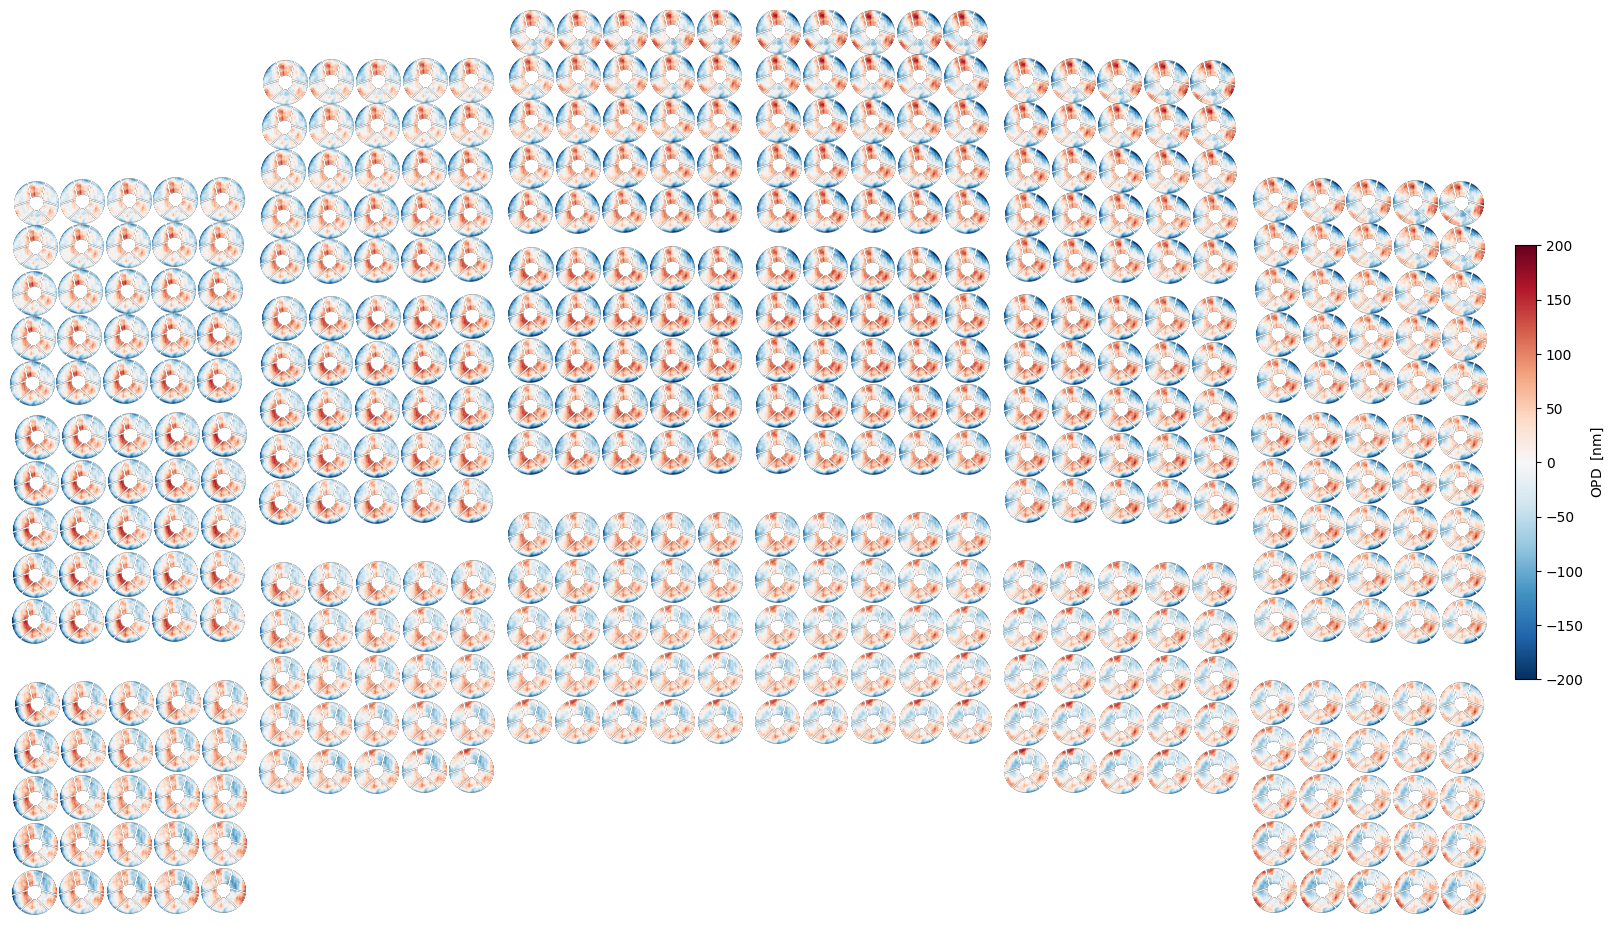

In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import stpsf

wfi = stpsf.WFI()
stpsf.roman._log.setLevel(40)

wfi.filter = 'F062'
wavelength = 0.62e-6

cmap = mpl.colormaps.get_cmap('RdBu_r')
norm = mpl.colors.Normalize(-200,200)

wficen = wfi.siaf['WFI_CEN']

aper = wfi.siaf[wfi.aperturename]
npad = aper.XSciSize/12
xsci_samples = ysci_samples = np.linspace(1+npad, aper.XSciSize+1-npad, 5)
xysci_grid = np.array([cgrid.flatten() for cgrid in np.meshgrid(xsci_samples, ysci_samples)]).T

ext_halfwidth = (aper.XSciSize/5)*wfi.pixelscale/2

fig,ax = plt.subplots(figsize=(18,15))

R = np.array([[np.cos(np.deg2rad(-60)), -np.sin(np.deg2rad(-60))],
              [np.sin(np.deg2rad(-60)),  np.cos(np.deg2rad(-60))]]) # Rot matrix for tel to sci orientation

extents = []
for sca in np.arange(1,19):
    wfi.detector = f'WFI{sca:02d}'
    aper = wfi.siaf[wfi.aperturename]
    for fov in np.arange(1,26):
        xysci = xysci_grid[fov-1]
        xytel = np.array(aper.sci_to_tel(*xysci))
        xyan = R @ np.array([xytel[0]-wficen.V2Ref, xytel[1]-wficen.V3Ref])

        wfi.detector_position = xysci

        # Construct the optical system
        osys = wfi.get_optical_system()

        # Construct a pupil wavefront
        wave = osys.input_wavefront(wavelength=wavelength)

        # First plane = pupil transmission + high-frequency OPD
        entrance_pupil = osys.planes[0]

        # Find the field-dependent Zernike optic
        zernike_optic = next(plane for plane in osys.planes
                             if isinstance(plane,stpsf.roman.FieldDependentAberration))

        opd_highfreq = entrance_pupil.get_opd(wave)*1e9
        opd_zernike = zernike_optic.get_opd(wave)*1e9

        opd_highfreq = np.where(opd_highfreq == 0, np.nan, opd_highfreq)
        opd_zernike = np.where(opd_zernike == 0, np.nan, opd_zernike)

        opd_total = opd_zernike + opd_highfreq

        extent = (-xyan[:,None] + np.array([-ext_halfwidth, ext_halfwidth])[None]).ravel()
        extents.append(extent)

        ax.imshow(opd_total, origin='lower', extent=extent, norm=norm, cmap=cmap)

fig.tight_layout()

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm, cmap),
                    ax=ax,
                    label='${\\rm OPD \\;\\; [nm]}$',
                    shrink=0.3,
                    pad=0.015)

[ax.spines[key].set_edgecolor('None') for key in ax.spines]
ax.set(xticks=[], yticks=[])

ax.set_xlim(np.percentile(np.array(extents)[..., :2], [0,100]))
ax.set_ylim(np.percentile(np.array(extents)[..., 2:], [0,100]))

## Characterization of Roman PSF across the focal plane

Using the reconstructed wavefront maps, we simulated Roman PSFs across a 5×5 grid on each WFI detector.

We use these simulations to characterize variations in common PSF properties across the focal plane, including:

- Full Width at Half Maximum (FWHM).
- Encircled Energy (EE).

For the example presented below, EE is evaluated within a radius of 0.3 arcsec (approximately 2.7 Roman WFI pixels).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import stpsf
import pysiaf
import gc
import os

# ---------------- USER SETTINGS ----------------
FILTER            = 'F129'     # Roman WFI filter
OVERSAMPLE        = 4          # oversampling used to build the PSF
FOV_ARCSEC        = 3.0        # PSF stamp size
EE_RADIUS_ARCSEC  = 0.3        # radius at which EE is evaluated (variable)
N_GRID            = 5          # NxN field points per detector
MARGIN_PIX        = 4          # keep grid points off the very edge of the SCA
MONOCHROMATIC_UM  = None       # e.g. 1.29 for monochromatic (fast); None = full bandpass (slow/heavy)
CSV_PATH          = 'roman_psf_results.csv' # Let's save the results so we don't re-run this cell for different visualizations
# -------------------------------------------------

siaf = pysiaf.Siaf('Roman')

Then we start our calculations per detector. Note that in this case we are saving the results in a separate CSV file. In this way you can play around with different visualizations without having to re-run the entire set of calculations.

In [ ]:
# --- figure out what's already done, and clean up any partial detector calculation, if any ---
completed_scas = set()
if os.path.exists(CSV_PATH):
    existing = pd.read_csv(CSV_PATH)
    counts = existing.groupby('sca').size()
    completed_scas = set(counts[counts == N_GRID * N_GRID].index)
    partial_scas = set(counts[counts != N_GRID * N_GRID].index)
    if partial_scas:
        print(f'Removing incomplete rows for: {sorted(partial_scas)}')
        existing = existing[~existing['sca'].isin(partial_scas)]
        existing.to_csv(CSV_PATH, index=False)
    print(f'Already complete: {sorted(completed_scas) if completed_scas else "none"}')

for n in range(1, 19):
    sca = f'SCA{n:02d}'
    if sca in completed_scas:
        print(f'{sca} already in {CSV_PATH}, skipping')
        continue

    ap_name = f'WFI{n:02d}_FULL'
    ap = siaf[ap_name]

    wfi = stpsf.roman.WFI()      # fresh instrument instance per detector
    wfi.filter = FILTER
    wfi.detector = sca

    xmin, xmax = MARGIN_PIX, ap.XSciSize - MARGIN_PIX
    ymin, ymax = MARGIN_PIX, ap.YSciSize - MARGIN_PIX
    xs = np.linspace(xmin, xmax, N_GRID)
    ys = np.linspace(ymin, ymax, N_GRID)

    rows = []
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            wfi.detector_position = (x, y)

            if MONOCHROMATIC_UM is not None:
                psf = wfi.calc_psf(oversample=OVERSAMPLE, fov_arcsec=FOV_ARCSEC,
                                    monochromatic=MONOCHROMATIC_UM * 1e-6)
            else:
                psf = wfi.calc_psf(oversample=OVERSAMPLE, fov_arcsec=FOV_ARCSEC)

            ee_func  = stpsf.measure_ee(psf, ext='OVERSAMP')
            ee_val   = ee_func(EE_RADIUS_ARCSEC)
            fwhm_val = stpsf.measure_fwhm(psf, ext='OVERSAMP')
            telx, tely = ap.sci_to_tel(x, y)

            rows.append(dict(sca=sca, i=i, j=j, x_pix=x, y_pix=y,
                              telx=telx, tely=tely, ee=ee_val, fwhm=fwhm_val))

            psf.close()
            del psf

        gc.collect()

    # write this detector's 25 rows to disk right away
    df_det = pd.DataFrame(rows)
    write_header = not os.path.exists(CSV_PATH)
    df_det.to_csv(CSV_PATH, mode='a', header=write_header, index=False)

    print(f'{sca} done, saved to {CSV_PATH}')

    del wfi
    gc.collect()

print('All detectors complete.')

Then we read the file and plot the results. 

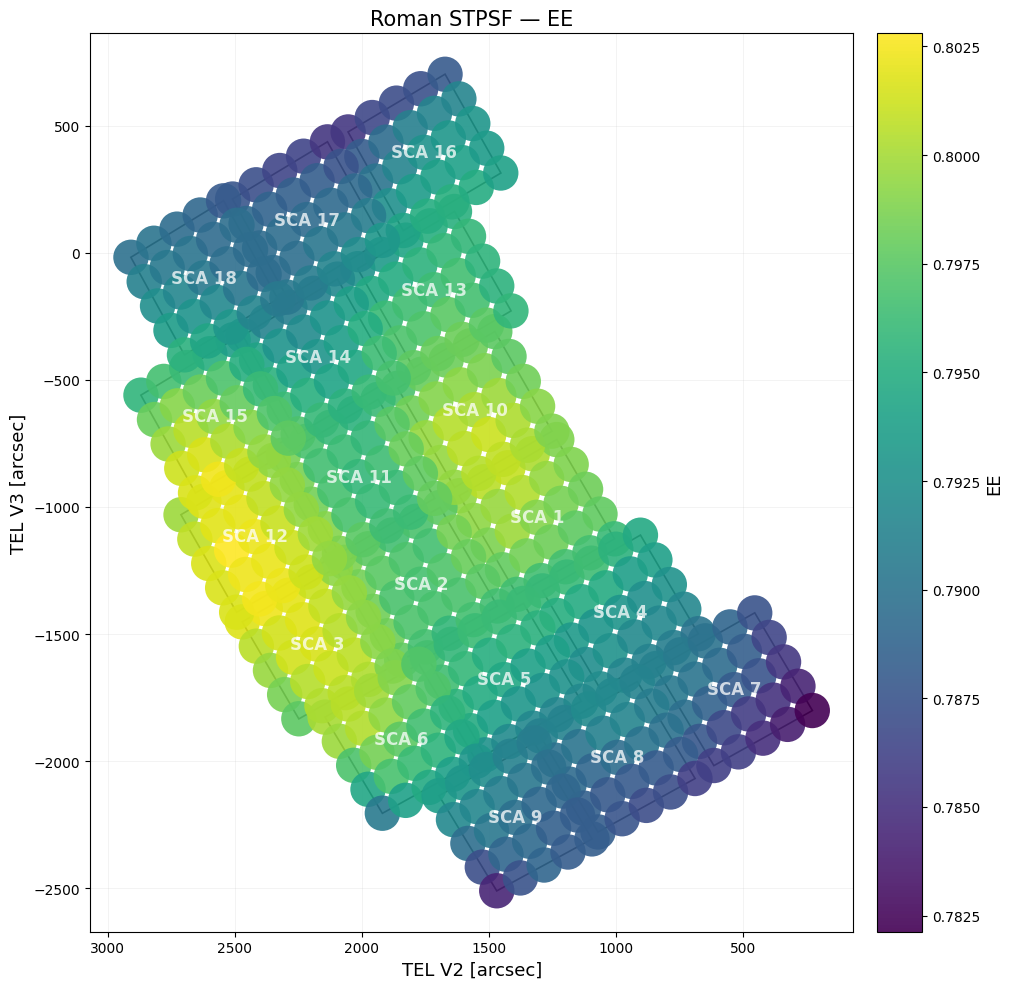

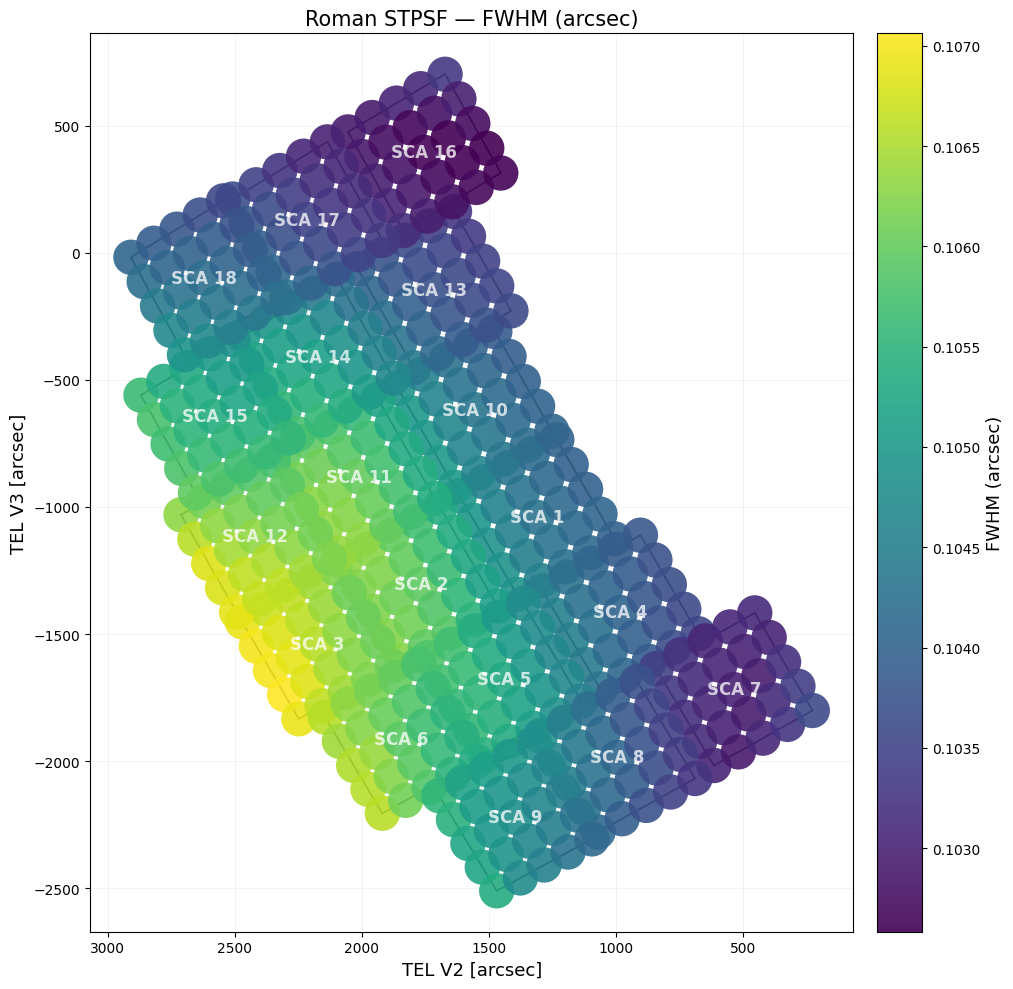

In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pysiaf


# ------------------------------------------------------------
# Read results
# ------------------------------------------------------------

df = pd.read_csv("roman_psf_results.csv")

siaf = pysiaf.Siaf("Roman")

df["sca_num"] = df["sca"].str.extract(r"(\d+)").astype(int)
scas = sorted(df["sca_num"].unique())


# ------------------------------------------------------------
# Get SCA footprints in TEL coordinates
# ------------------------------------------------------------

footprints = {}

for n in scas:

    ap = siaf[f"WFI{n:02d}_FULL"]

    x = np.array([1, ap.XSciSize, ap.XSciSize, 1])
    y = np.array([1, 1, ap.YSciSize, ap.YSciSize])

    telx, tely = ap.sci_to_tel(x, y)

    footprints[n] = np.column_stack((telx, tely))


# ------------------------------------------------------------
# Plot function
# ------------------------------------------------------------

def plot_psf(quantity, label):

    fig, ax = plt.subplots(figsize=(13, 10))

    # --------------------------------------------------------
    # Color scale
    # --------------------------------------------------------

    vmin = df[quantity].min()
    vmax = df[quantity].max()

    # --------------------------------------------------------
    # Plot detector footprints
    # --------------------------------------------------------

    for n in scas:

        footprint = footprints[n]

        ax.add_patch(
            Polygon(
                footprint,
                closed=True,
                facecolor="none",
                edgecolor="black",
                linewidth=1.2,
                zorder=2
            )
        )

    # --------------------------------------------------------
    # Plot the 5 x 5 measurements
    #
    # Large markers intentionally overlap to make the
    # distribution look more continuous.
    # --------------------------------------------------------

    sc = ax.scatter(
        df["telx"],
        df["tely"],
        c=df[quantity],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        s=650,                 # increase/decrease for smoothness
        marker="o",
        edgecolor="none",
        alpha=0.90,
        zorder=3
    )

    # --------------------------------------------------------
    # Detector labels
    # --------------------------------------------------------

    for n in scas:

        footprint = footprints[n]

        cx = footprint[:, 0].mean()
        cy = footprint[:, 1].mean()

        ax.text(
            cx,
            cy,
            f"SCA {n}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white",
            alpha=0.75,
            zorder=5
        )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        sc,
        ax=ax,
        pad=0.02,
        fraction=0.045
    )

    cbar.set_label(
        label,
        fontsize=13
    )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_aspect("equal")

    ax.set_xlabel(
        "TEL V2 [arcsec]",
        fontsize=13
    )

    ax.set_ylabel(
        "TEL V3 [arcsec]",
        fontsize=13
    )

    ax.set_title(
        f"Roman STPSF — {label}",
        fontsize=15
    )

    # --------------------------------------------------------
    # Limits
    # --------------------------------------------------------

    xy = np.vstack(
        list(footprints.values())
    )

    margin = 0.05 * max(
        xy[:, 0].max() - xy[:, 0].min(),
        xy[:, 1].max() - xy[:, 1].min()
    )

    ax.set_xlim(
        xy[:, 0].min() - margin,
        xy[:, 0].max() + margin
    )

    ax.set_ylim(
        xy[:, 1].min() - margin,
        xy[:, 1].max() + margin
    )
    # Roman TEL convention: +V2 increases to the left
    ax.invert_xaxis()
    ax.grid(
        alpha=0.15,
        linewidth=0.7
    )

    plt.tight_layout()

    return fig, ax


# ============================================================
# EE
# ============================================================

fig_ee, ax_ee = plot_psf(
    "ee",
    "EE"
)

plt.show()


# ============================================================
# FWHM
# ============================================================

fig_fwhm, ax_fwhm = plot_psf(
    "fwhm",
    "FWHM (arcsec)"
)

plt.show()



> **Key Result**
>
> EE and FWHM show multi-field variations, however, these variations are quantitatively small

## Comparison between STPSF v2.2.0 and STPSF v2.3.0

The primary change in the Roman optical model between STPSF v2.2.0 and v2.3.0 is the increased field sampling provided by the post-SCIPA model.

The previous model represented each detector using five field positions, whereas the new model represents each detector using a 5×5 grid of 25 field positions.

The figures below compare the resulting EE and FWHM distributions across the Roman focal plane.

The denser 5×5 sampling provides a more detailed representation of the spatial variation of the PSF properties across the WFI field.

**Figure 8 — Encircled Energy fraction Multi-field variations. STPSF v2.2.0**

<img src="./roman_figures/ee-fov_v2_2_0.png"
     alt="EE variations"
     width="600">

**Caption**

*Encircled Energy fraction Multi-field variations. STPSF v2.2.0*

**Figure 9 — Roman FWHM  Multi-field variations. STPSF v2.2.0**

<img src="./roman_figures/fwhm-fov_v2_2_0.png"
     alt="FWHM variations"
     width="600">

**Caption**

*Roman FWHMn Multi-field variations. STPSF v2.2.0*

## Conclusions

The post-SCIPA Roman optical delivery provides substantially improved field sampling compared with the optical model used in previous STPSF releases.

We developed a compact representation of this model using Zernike coefficients through Z210 together with detector-specific high-frequency residual maps.
 
This approach:

- increases the field sampling from 5 to 25 positions per detector;
- preserves detector-dependent high-spatial-frequency structure;
- efficiently represents the wavelength dependence of the wavefront;
- reconstructs the original post-SCIPA wavefront maps with an RMS residual of approximately 12 nm; and
- substantially reduces the amount of optical reference data that must be distributed with STPSF.

The resulting model provides STPSF users with a substantially more densely sampled representation of the Roman WFI optical wavefront while maintaining a practical reference-data package.

# Important note about pupil orientation

All the phase maps distributed in stpsf-data use the Roman entrance pupil orientation. This is for consistency with the preferred orientacion of the optical data provide by NASA. The Roman PSF simulation, however, uses the Roman exit pupil orientation. This matches the Roman PSF as observed in the detector frame of reference. 

The figure below shows the different planes in the STPSF simulation, including the transformation between entrance and exit pupil. 

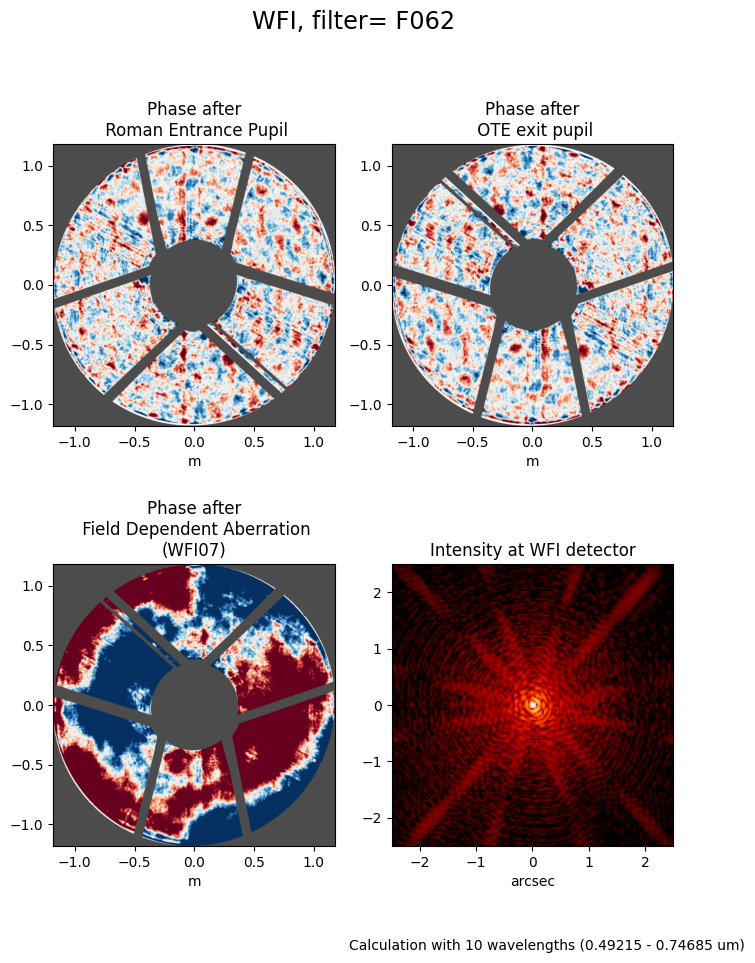

In [10]:
plt.figure(figsize = [8,10])
wfi = stpsf.WFI()
wfi.filter = 'F062'
wfi.detector = 'WFI07'
fov_pixels = 256
psf = wfi.calc_psf(display = True, fov_pixels = fov_pixels)